# <center> ISEL - AA </center>
## <center>Semestre 2025/26 </center>
###  <center> Trabalho 2 - Classificação de Críticas de Cinema do IMDb</center>

Trabalho realizado por:
* Lucas Duarte, número <b> 50735 </b>
* Rafael Dias, número <b> 50773 </b>
* Miguel Sedas, número <b> 50801  </b>

<b> Turma 52D </b> <br></br>
<b> Docente: Gonçalo Xufre </b>

# Introdução

Escrever introdução

## Imports

In [8]:
import pickle
import re
from pydoc import doc
from typing import Counter

import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    mean_squared_error,
    ConfusionMatrixDisplay
)
from nltk.stem import SnowballStemmer


## Carregamento de dados

In [2]:
with open("imdbFull.p", "rb") as data_file: 
    D = pickle.load(data_file)
    
print(D.keys(), "\n")
print(D.DESCR)

dict_keys(['data', 'target', 'DESCR']) 

This dataset contains movie reviews along with their associated binary sentiment polarity labels. It is intended to serve as a benchmark for sentiment classification. This document outlines how the dataset was gathered, and how to use the files provided.
For more details see: http://ai.stanford.edu/~amaas/data/sentiment/


50000
[ 1  2  3  4  7  8  9 10]


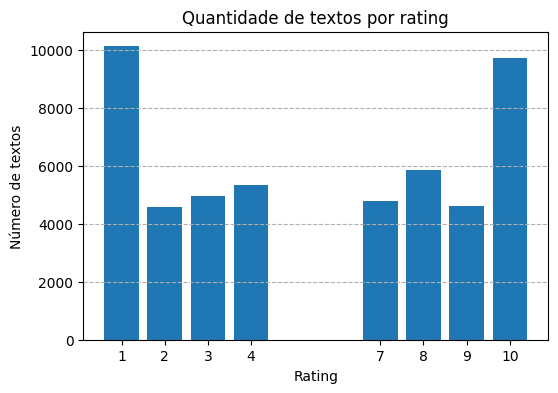

In [7]:
# Extrair dados
Docs = D["data"]
y = D["target"]

print(len(y))
print(np.unique(y))

# Contar textos por rating
unique, counts = np.unique(y, return_counts=True)

# Gráfico
plt.figure(figsize=(6, 4))
plt.bar(unique, counts)
plt.xlabel("Rating")
plt.ylabel("Número de textos")
plt.title("Quantidade de textos por rating")
plt.xticks(unique)
plt.grid(axis='y', linestyle='--')
plt.show()

Como é possível observar acima, verifica-se que o dataset tem as classes representantes das notas "5" e "6" eliminadas. O gráfico acima criado ajuda oferece uma forma mais visual de como estão distribuidas o número de críticas por "rating".

# Construção do Vocabulário

## Divisão dos dados em subconjuntos

No trabalho anterior (TP1) foi realizada uma divisão dos dados em três subconjuntos distintos — treino, validação e teste — de forma a garantir uma avaliação rigorosa e imparcial dos modelos. No presente trabalho seguiu-se exatamente a mesma metodologia, repetindo a divisão tripartida dos dados por consistência experimental e para assegurar a comparabilidade entre abordagens.

A divisão utilizada foi a seguinte: 50% dos dados para treino, 30% para validação e 20% para teste. Esta distribuição permite um equilíbrio adequado entre os diferentes objetivos da modelação.
O conjunto de treino (50%) fornece uma quantidade suficiente de exemplos para aprender os padrões relevantes presentes nas críticas de cinema. O conjunto de validação (30%) é utilizado durante o desenvolvimento para testar combinações de hiperparâmetros, escolher o melhor vocabulário TF-IDF e selecionar os modelos mais eficazes sem recorrer aos dados de teste. Por fim, o conjunto de teste (20%) é completamente isolado até ao final do trabalho e serve para obter uma estimativa imparcial do desempenho real dos modelos perante dados nunca antes observados.

In [12]:
# Proporções de cada conjunto
treino_ratio = 0.5
valid_ratio = 0.3

# Tamanhos para cada conjunto
treino_size = int(len(Docs) * treino_ratio)
valid_size = int(len(Docs) * valid_ratio)

# Dividir X e y entre treino, validação e teste
X_train = Docs[:treino_size]
y_train = y[:treino_size]

X_valid = Docs[treino_size:treino_size + valid_size]
y_valid = y[treino_size:treino_size + valid_size]

X_test = Docs[treino_size + valid_size:]
y_test = y[treino_size + valid_size:]

# Print dos tamanhos de cada conjunto
print("Conjunto de treino:", len(X_train), len(y_train))
print("Conjunto de validação:", len(X_valid), len(y_valid))
print("Conjunto de teste:", len(X_test), len(y_test))

Conjunto de treino: 25000 25000
Conjunto de validação: 15000 15000
Conjunto de teste: 10000 10000


## Limpeza do Texto

A limpeza do texto é uma etapa fundamental, sobretudo quando se trabalha com modelos que dependem diretamente da qualidade das representações textuais, como o TF-IDF. Os textos originais, especialmente em bases de dados reais como o IMDb, contêm elementos que não contribuem para o significado — tags HTML, pontuação desnecessária, letras maiúsculas misturadas, múltiplos espaços ou símbolos que apenas aumentam o ruído. Se estes elementos forem mantidos, acabam por inflacionar artificialmente o vocabulário, criando milhares de "palavras" diferentes que o modelo interpreta como termos relevantes, mas que não têm qualquer utilidade semântica. Uma boa limpeza reduz este ruído, normaliza o texto e garante que palavras que representam a mesma ideia tenham exatamente a mesma forma.

Outro componente crucial do pré-processamento é o stemming. O stemming consiste em reduzir cada palavra à sua raiz ou forma base, cortando prefixos ou sufixos. Por exemplo, palavras como loved, loving e loves tornam-se love. Esta normalização traz duas vantagens importantes: diminui ainda mais o tamanho do vocabulário e aumenta a densidade da informação, porque várias formas flexionadas passam a ser tratadas como a mesma palavra. Isto permite ao modelo capturar melhor os padrões subjacentes ao sentimento das críticas, em vez de desperdiçar capacidade a distinguir variações irrelevantes de uma mesma palavra. Embora seja um processo agressivo que pode gerar formas artificiais, na prática costuma melhorar o desempenho de classificadores e regressões baseadas em TF-IDF, especialmente em conjuntos de dados grandes como este.

Assim, tanto a limpeza de texto quanto o stemming são etapas essenciais para garantir um vocabulário mais compacto, consistente e sem ruído, permitindo que os modelos foquem nos padrões realmente informativos presentes nas críticas.

In [ ]:
# -----------------------------
# 1. Função de limpeza
# -----------------------------

def clean_text(doc):
    # 1. Remover quebras HTML específicas do IMDb
    doc = doc.replace('<br />', ' ')

    # 2. Lowercase (importante antes de regex e stemming)
    doc = doc.lower()

    # 3. Remover tudo o que não seja letras (inclui acentos)
    doc = re.sub(r'[^a-zA-Z\u00C0-\u00FF]+', ' ', doc)

    # 4. Remover espaços múltiplos
    doc = re.sub(r'\s+', ' ', doc).strip()

    return doc

Docs_clean = [clean_text(doc) for doc in Docs]

print("Exemplo antes:")
print(Docs[0][:300])

print("\nExemplo depois da limpeza:")
print(Docs_clean[0][:300])


# -----------------------------
# 2. Aplicar stemming
# -----------------------------

stemmer = SnowballStemmer("english")

def stem_text(doc):
    return ' '.join(stemmer.stem(w) for w in doc.split())

Docs_stemmed = [stem_text(doc) for doc in Docs_clean]

print("\nExemplo após stemming:")
print(Docs_stemmed[0][:300])

Exemplo antes:
Zero Day leads you to think, even re-think why two boys/young men would do what they did - commit mutual suicide via slaughtering their classmates. It captures what must be beyond a bizarre mode of being for two humans who have decided to withdraw from common civility in order to define their own/mu

Exemplo depois da limpeza:
zero day leads you to think even re think why two boys young men would do what they did commit mutual suicide via slaughtering their classmates it captures what must be beyond a bizarre mode of being for two humans who have decided to withdraw from common civility in order to define their own mutual

Exemplo após stemming:
zero day lead you to think even re think whi two boy young men would do what they did commit mutual suicid via slaughter their classmat it captur what must be beyond a bizarr mode of be for two human who have decid to withdraw from common civil in order to defin their own mutual world via coupl dest
